# Ноутбук 01: Быстрый старт с Transformers 

**Цель:** пройти 5 NLP-задач на русскоязычных примерах и показать не только код, но и сравнения, метрики и сохраненные результаты.

Что улучшено:
- весь ноутбук переведён с англоязычных примеров на русскоязычные;
- для каждой задачи подобраны другие модели, более подходящие под русский язык;
- добавлены таблицы, метрики и графики;
- добавлены сравнения настроек/подходов


In [1]:
# Установка библиотек (если ещё не установлены)
# Раскомментируйте и запустите один раз:
# %pip install -q transformers torch datasets matplotlib pandas sentencepiece protobuf

In [2]:
import re
import string
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from IPython.display import display
from huggingface_hub.utils import disable_progress_bars
from transformers import (
    __version__ as transformers_version,
    pipeline,
    set_seed,
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
)

disable_progress_bars()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

device = 0 if torch.cuda.is_available() else -1
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'transformers: {transformers_version}')
print(f'torch: {torch.__version__}')
print(f'device: {device_name}')


c:\anacon\envs\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.3.0
torch: 2.9.1+cu126
device: cuda


## Задача 1: Анализ тональности

Используем русскоязычную модель `blanchefort/rubert-base-cased-sentiment-rurewiews`.

Добавлено:
- мини-набор русских примеров с ручной разметкой;
- расчет Accuracy и матрицы ошибок;
- график уверенности модели.


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4079.39it/s]
BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment-rurewiews
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Прогнозы по каждому примеру:


,text,gold_label,pred_label,confidence,is_correct
0,Фильм оказался удивительно глубоким и трогател...,POSITIVE,POSITIVE,0.993708,True
1,"Снято дешево, актеры переигрывают, смотреть не...",NEGATIVE,NEGATIVE,0.718982,True
2,"Фильм на один вечер: не плохо и не отлично, пр...",NEUTRAL,NEUTRAL,0.843100,True
3,Это лучший фильм года: сильный сценарий и потр...,POSITIVE,POSITIVE,0.991674,True
4,"Полный провал: скучно, затянуто и совершенно н...",NEGATIVE,NEGATIVE,0.771410,True
5,"Средняя картина, без явных плюсов и явных мину...",NEUTRAL,NEUTRAL,0.870325,True


Точность на мини-наборе: 100.0%
Матрица ошибок:


pred_label,NEGATIVE,NEUTRAL,POSITIVE,All
gold_label,,,,
NEGATIVE,2,0,0,2
NEUTRAL,0,2,0,2
POSITIVE,0,0,2,2
All,2,2,2,6


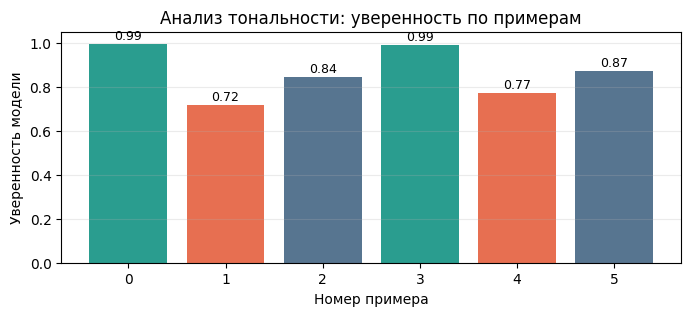

In [3]:
sentiment_samples = pd.DataFrame(
    [
        ('Фильм оказался удивительно глубоким и трогательным, рекомендую к просмотру.', 'POSITIVE'),
        ('Снято дешево, актеры переигрывают, смотреть невозможно.', 'NEGATIVE'),
        ('Фильм на один вечер: не плохо и не отлично, просто средне.', 'NEUTRAL'),
        ('Это лучший фильм года: сильный сценарий и потрясающая музыка.', 'POSITIVE'),
        ('Полный провал: скучно, затянуто и совершенно неинтересно.', 'NEGATIVE'),
        ('Средняя картина, без явных плюсов и явных минусов.', 'NEUTRAL'),
    ],
    columns=['text', 'gold_label'],
)

sentiment_model_id = 'blanchefort/rubert-base-cased-sentiment-rurewiews'
sentiment_pipe = pipeline(
    task='text-classification',
    model=sentiment_model_id,
    device=device,
)

sentiment_predictions = sentiment_pipe(sentiment_samples['text'].tolist(), truncation=True)

sentiment_samples['pred_label'] = [pred['label'] for pred in sentiment_predictions]
sentiment_samples['confidence'] = [float(pred['score']) for pred in sentiment_predictions]
sentiment_samples['is_correct'] = sentiment_samples['gold_label'] == sentiment_samples['pred_label']

print('Прогнозы по каждому примеру:')
display(sentiment_samples)

sentiment_accuracy = sentiment_samples['is_correct'].mean()
print(f'Точность на мини-наборе: {sentiment_accuracy:.1%}')

sentiment_cm = pd.crosstab(
    sentiment_samples['gold_label'],
    sentiment_samples['pred_label'],
    margins=True,
)
print('Матрица ошибок:')
display(sentiment_cm)

color_map = {'POSITIVE': '#2a9d8f', 'NEGATIVE': '#e76f51', 'NEUTRAL': '#577590'}
plt.figure(figsize=(8, 3))
bars = plt.bar(
    sentiment_samples.index.astype(str),
    sentiment_samples['confidence'],
    color=[color_map[label] for label in sentiment_samples['pred_label']],
)
plt.ylim(0, 1.05)
plt.xlabel('Номер примера')
plt.ylabel('Уверенность модели')
plt.title('Анализ тональности: уверенность по примерам')
plt.grid(axis='y', alpha=0.25)

for bar, value in zip(bars, sentiment_samples['confidence']):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}', ha='center', fontsize=9)

plt.show()



## Задача 2: Распознавание именованных сущностей (NER)

Используем мультиязычную модель `Davlan/bert-base-multilingual-cased-ner-hrl` и русский текст.

Добавлено:
- сравнение сырых токенов и сгруппированных сущностей;
- распределение сущностей по типам.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3100.61it/s]
BertForTokenClassification LOAD REPORT from: Davlan/bert-base-multilingual-cased-ner-hrl
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9819.26it/s]
BertForTokenClassification LOAD REPORT from: Davlan/bert-base-multilingual-cased-ner-hrl
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Сырых предсказаний: 16
После aggregation_strategy="first": 5

Первые 10 сырых токенов:


,entity,score,index,word,start,end
0,B-ORG,0.976928,1,С,0,1
1,I-ORG,0.956306,2,##бер,1,4
2,I-ORG,0.974240,3,##бан,4,7
3,I-ORG,0.925457,4,##к,7,8
4,B-LOC,0.999844,12,Москве,29,35
5,B-PER,0.999854,15,Ил,39,41
6,I-PER,0.984492,16,##он,41,43
7,I-PER,0.999767,17,М,44,45
8,I-PER,0.999725,18,##ас,45,47
9,I-PER,0.999349,19,##к,47,48


Сгруппированные сущности:


,word,entity_type,score,start,end
0,Сбербанк,ORG,0.976928,0,8
1,Москве,LOC,0.999844,29,35
2,Илон Маск,PER,0.999810,39,48
3,Санкт - Петербург,LOC,0.999828,57,72
4,Яндекса,ORG,0.999108,104,111


Количество сущностей по типам:


,entity_type,count
0,ORG,2
1,LOC,2
2,PER,1


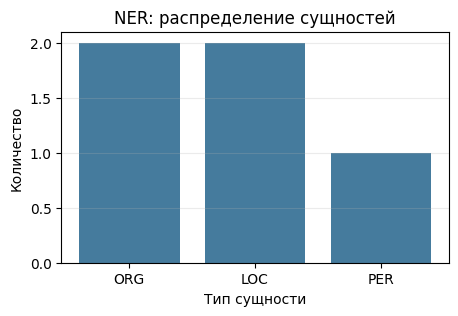

In [4]:
ner_text = (
    'Сбербанк открыл новый офис в Москве, '
    'а Илон Маск посетил Санкт-Петербург и встретился с представителями Яндекса.'
)

ner_model_id = 'Davlan/bert-base-multilingual-cased-ner-hrl'
ner_raw_pipe = pipeline(
    task='token-classification',
    model=ner_model_id,
    device=device,
)

ner_grouped_pipe = pipeline(
    task='token-classification',
    model=ner_model_id,
    aggregation_strategy='first',
    device=device,
)

raw_entities = ner_raw_pipe(ner_text)
grouped_entities = ner_grouped_pipe(ner_text)

print(f'Сырых предсказаний: {len(raw_entities)}')
print(f'После aggregation_strategy="first": {len(grouped_entities)}')
print()
print('Первые 10 сырых токенов:')
display(pd.DataFrame(raw_entities).head(10))

ner_df = pd.DataFrame(grouped_entities)[['word', 'entity_group', 'score', 'start', 'end']]
ner_df = ner_df.rename(columns={'entity_group': 'entity_type'})

print('Сгруппированные сущности:')
display(ner_df)

entity_counts = (
    ner_df['entity_type']
    .value_counts()
    .rename_axis('entity_type')
    .reset_index(name='count')
)

print('Количество сущностей по типам:')
display(entity_counts)

plt.figure(figsize=(5, 3))
plt.bar(entity_counts['entity_type'], entity_counts['count'], color='#457b9d')
plt.title('NER: распределение сущностей')
plt.xlabel('Тип сущности')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.25)
plt.show()


## Задача 3: Вопрос-ответ (extractive QA)

Используем мультиязычную модель `mrm8488/bert-multi-cased-finetuned-xquadv1`.

Добавлено:
- русский контекст и русские вопросы;
- метрика Exact Match на мини-наборе.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3508.79it/s]
BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-multi-cased-finetuned-xquadv1
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,question,predicted_answer,expected,confidence,exact_match
0,В каком году была представлена архитектура Tra...,2017,2017,0.790243,True
1,Кто предложил архитектуру Transformer?,Васвани и коллеги из Google Brain,Васвани и коллеги из Google Brain,0.685565,True
2,Для какой задачи Transformer создавался изнача...,машинного перевода,машинного перевода,0.871176,True


Exact Match на мини-наборе QA: 100.0%


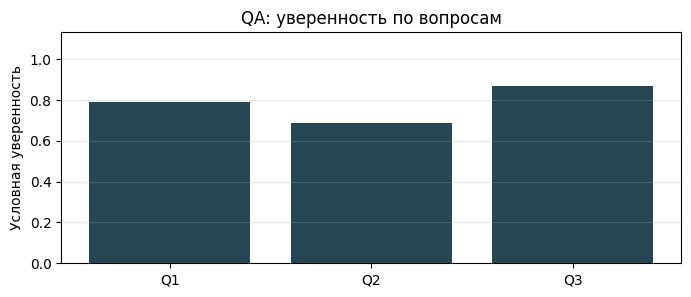

In [5]:
qa_model_id = 'mrm8488/bert-multi-cased-finetuned-xquadv1'
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_id)
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_model_id)
qa_model.eval()

qa_context = (
    'Архитектура Transformer была представлена в 2017 году в статье «Attention Is All You Need». '
    'Авторами считаются Васвани и коллеги из Google Brain. '
    'Модель отказалась от рекуррентных слоев и использовала механизм self-attention. '
    'Изначально Transformer создавался для задач машинного перевода.'
)

qa_items = [
    ('В каком году была представлена архитектура Transformer?', ['2017']),
    ('Кто предложил архитектуру Transformer?', ['Васвани и коллеги из Google Brain', 'Васвани']),
    ('Для какой задачи Transformer создавался изначально?', ['машинного перевода']),
]


def normalize_text(text: str) -> str:
    text = text.lower()
    text = text.replace('ё', 'е')
    punctuation = string.punctuation + '«»—–…'
    text = ''.join(ch for ch in text if ch not in punctuation)
    text = re.sub(r'\s+', ' ', text).strip()
    return text



def answer_question(question: str, context: str):
    inputs = qa_tokenizer(
        question,
        context,
        return_tensors='pt',
        truncation=True,
        max_length=512,
    )

    with torch.no_grad():
        outputs = qa_model(**inputs)

    start_probs = torch.softmax(outputs.start_logits[0], dim=0)
    end_probs = torch.softmax(outputs.end_logits[0], dim=0)

    start_idx = int(torch.argmax(start_probs))
    end_idx = int(torch.argmax(end_probs[start_idx:])) + start_idx

    answer_ids = inputs['input_ids'][0][start_idx : end_idx + 1]
    answer = qa_tokenizer.decode(answer_ids, skip_special_tokens=True).strip()

    confidence = float((start_probs[start_idx] * end_probs[end_idx]).item())
    return answer, confidence


qa_rows = []
for question, references in qa_items:
    predicted_answer, confidence = answer_question(question, qa_context)
    predicted_norm = normalize_text(predicted_answer)
    reference_norms = [normalize_text(ref) for ref in references]
    exact_match = predicted_norm in reference_norms

    qa_rows.append(
        {
            'question': question,
            'predicted_answer': predicted_answer,
            'expected': references[0],
            'confidence': confidence,
            'exact_match': exact_match,
        }
    )

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

qa_exact_match = qa_df['exact_match'].mean()
print(f'Exact Match на мини-наборе QA: {qa_exact_match:.1%}')

plt.figure(figsize=(8, 3))
plt.bar(range(len(qa_df)), qa_df['confidence'], color='#264653')
plt.xticks(range(len(qa_df)), [f'Q{i + 1}' for i in range(len(qa_df))])
plt.ylim(0, max(qa_df['confidence']) * 1.3)
plt.ylabel('Условная уверенность')
plt.title('QA: уверенность по вопросам')
plt.grid(axis='y', alpha=0.25)
plt.show()


## Задача 4: Суммаризация

Для русскоязычного текста используем модель `IlyaGusev/rut5_base_sum_gazeta`.

Добавлено:
- сравнение с простым baseline `Lead-2` (извлекающий подход);
- сравнение двух ограничений длины генерации;
- расчет коэффициента сжатия.


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 16851.51it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Both `max_new_tokens` (=45) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentatio

Длина исходного текста: 77 слов


,approach,summary_words,compression_ratio
0,Lead-2 baseline (извлекающий),33,0.428571
1,ruT5 max_new_tokens=45,24,0.311688
2,ruT5 max_new_tokens=90,32,0.415584


Lead-2 baseline (извлекающий):
Крупные языковые модели активно применяются в поиске, поддержке клиентов, образовании и разработке ПО Они сокращают время на подготовку текстов и анализ данных, но при этом могут галлюцинировать факты и иногда выдают нестабильные ответы

ruT5 max_new_tokens=45:
Крупные языковые модели активно применяются в поиске, поддержке клиентов, образовании и разработке ПО. Они сокращают время на подготовку текстов и анализ данных, но при

ruT5 max_new_tokens=90:
Крупные языковые модели активно применяются в поиске, поддержке клиентов, образовании и разработке ПО. Они сокращают время на подготовку текстов и анализ данных, но при этом могут галлюцинировать факты и выдать нестабильные ответы.



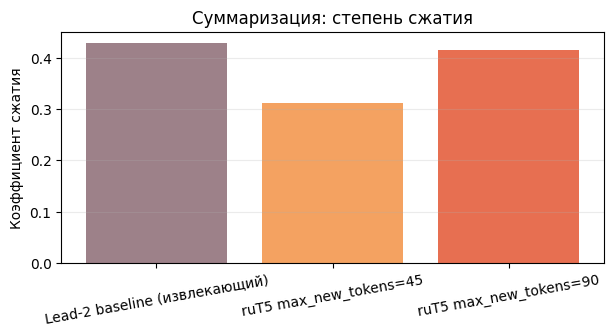

In [6]:
summarization_model_id = 'IlyaGusev/rut5_base_sum_gazeta'
sum_tokenizer = AutoTokenizer.from_pretrained(summarization_model_id)
sum_model = AutoModelForSeq2SeqLM.from_pretrained(summarization_model_id)
sum_model.eval()

article = (
    'Крупные языковые модели активно применяются в поиске, поддержке клиентов, образовании и разработке ПО. '
    'Они сокращают время на подготовку текстов и анализ данных, но при этом могут галлюцинировать факты и иногда выдают нестабильные ответы. '
    'Чтобы повысить надежность, команды используют retrieval, инженеринг промптов и автоматические проверки качества. '
    'Одновременно развивается сжатие моделей: дистилляция и квантизация уменьшают задержку и стоимость инференса на CPU и edge-устройствах. '
    'В реальных продуктах приходится балансировать качество, скорость ответа и бюджет, а не оптимизировать только одну метрику.'
)


def generate_summary(max_new_tokens: int) -> str:
    inputs = sum_tokenizer(article, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():
        output_ids = sum_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            no_repeat_ngram_size=3,
            do_sample=False,
        )
    return sum_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


lead2_summary = ' '.join(article.split('. ')[:2]).strip()
summary_short = generate_summary(max_new_tokens=45)
summary_long = generate_summary(max_new_tokens=90)

summary_df = pd.DataFrame(
    [
        {'approach': 'Lead-2 baseline (извлекающий)', 'summary': lead2_summary},
        {'approach': 'ruT5 max_new_tokens=45', 'summary': summary_short},
        {'approach': 'ruT5 max_new_tokens=90', 'summary': summary_long},
    ]
)

source_words = len(article.split())
summary_df['source_words'] = source_words
summary_df['summary_words'] = summary_df['summary'].str.split().str.len()
summary_df['compression_ratio'] = summary_df['summary_words'] / summary_df['source_words']

print(f'Длина исходного текста: {source_words} слов')
display(summary_df[['approach', 'summary_words', 'compression_ratio']])

for _, row in summary_df.iterrows():
    print(f"{row['approach']}:")
    print(row['summary'])
    print()

plt.figure(figsize=(7, 3))
plt.bar(summary_df['approach'], summary_df['compression_ratio'], color=['#9d8189', '#f4a261', '#e76f51'])
plt.ylabel('Коэффициент сжатия')
plt.title('Суммаризация: степень сжатия')
plt.xticks(rotation=10)
plt.grid(axis='y', alpha=0.25)
plt.show()


## Задача 5: Генерация текста

Используем русскоязычную генеративную модель `sberbank-ai/rugpt3small_based_on_gpt2`.

Сравниваем два режима:
- `Жадный режим` (`do_sample=False`) для повторяемости;
- `Сэмплирование` (`do_sample=True`) для разнообразия.


Loading weights: 100%|██████████| 149/149 [00:00<?, ?it/s]
The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,mode,generated_text,word_count
0,Жадный режим,В ближайшие пять лет большие языковые модели б...,40
1,Сэмплирование #1,В ближайшие пять лет большие языковые модели б...,27
2,Сэмплирование #2,В ближайшие пять лет большие языковые модели б...,36
3,Сэмплирование #3,В ближайшие пять лет большие языковые модели б...,42


Жадный режим: уникальных ответов при 3 повторах = 1 / 3
Сэмплирование: уникальных ответов = 3 / 3


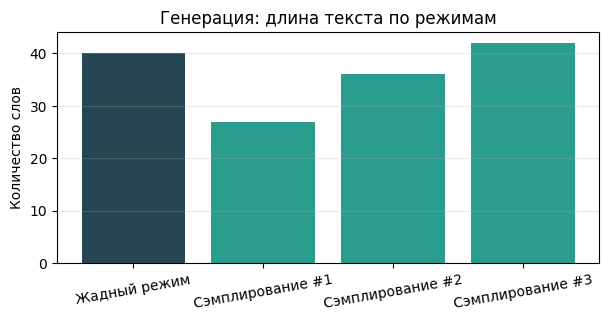

In [7]:
generation_model_id = 'sberbank-ai/rugpt3small_based_on_gpt2'
gen_tokenizer = AutoTokenizer.from_pretrained(generation_model_id)
gen_model = AutoModelForCausalLM.from_pretrained(generation_model_id)
gen_model.eval()

if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token

prompt = 'В ближайшие пять лет большие языковые модели будут'


def clean_text(text: str) -> str:
    return ' '.join(text.split())



def generate_text(prompt_text: str, do_sample: bool, num_return_sequences: int = 1):
    model_inputs = gen_tokenizer(prompt_text, return_tensors='pt')

    generation_kwargs = {
        'max_new_tokens': 45,
        'do_sample': do_sample,
        'num_return_sequences': num_return_sequences,
        'pad_token_id': gen_tokenizer.eos_token_id,
    }

    if do_sample:
        generation_kwargs.update({'temperature': 0.9, 'top_p': 0.92})

    with torch.no_grad():
        output_ids = gen_model.generate(**model_inputs, **generation_kwargs)

    return [clean_text(gen_tokenizer.decode(ids, skip_special_tokens=True)) for ids in output_ids]


greedy_output = generate_text(prompt, do_sample=False, num_return_sequences=1)[0]
sampled_outputs = generate_text(prompt, do_sample=True, num_return_sequences=3)

greedy_repeats = [generate_text(prompt, do_sample=False, num_return_sequences=1)[0] for _ in range(3)]

generation_df = pd.DataFrame(
    [{'mode': 'Жадный режим', 'generated_text': greedy_output}]
    + [
        {'mode': f'Сэмплирование #{i + 1}', 'generated_text': text}
        for i, text in enumerate(sampled_outputs)
    ]
)

generation_df['word_count'] = generation_df['generated_text'].str.split().str.len()
display(generation_df)

print(f'Жадный режим: уникальных ответов при 3 повторах = {len(set(greedy_repeats))} / 3')
print(f'Сэмплирование: уникальных ответов = {len(set(sampled_outputs))} / 3')

plt.figure(figsize=(7, 3))
plt.bar(generation_df['mode'], generation_df['word_count'], color=['#264653', '#2a9d8f', '#2a9d8f', '#2a9d8f'])
plt.ylabel('Количество слов')
plt.title('Генерация: длина текста по режимам')
plt.xticks(rotation=10)
plt.grid(axis='y', alpha=0.25)
plt.show()


In [8]:
final_metrics = pd.DataFrame(
    [
        {'task': 'Анализ тональности', 'metric': 'Точность', 'value': f'{sentiment_accuracy:.1%}'},
        {'task': 'NER', 'metric': 'Сущностей после группировки', 'value': str(len(ner_df))},
        {'task': 'Вопрос-ответ', 'metric': 'Exact Match', 'value': f'{qa_exact_match:.1%}'},
        {
            'task': 'Суммаризация',
            'metric': 'Лучший коэффициент сжатия',
            'value': f"{summary_df['compression_ratio'].min():.2f}",
        },
        {
            'task': 'Генерация',
            'metric': 'Уникальных ответов в sampling (из 3)',
            'value': str(len(set(sampled_outputs))),
        },
    ]
)

print('Сводные метрики ноутбука:')
display(final_metrics)


Сводные метрики ноутбука:


,task,metric,value
0,Анализ тональности,Точность,100.0%
1,NER,Сущностей после группировки,5
2,Вопрос-ответ,Exact Match,100.0%
3,Суммаризация,Лучший коэффициент сжатия,0.31
4,Генерация,Уникальных ответов в sampling (из 3),3
